# 이미지 하단부를 예측(복원)하는 RNN 프로젝트
400장의 얼굴 이미지를 증강하여 전체 800장으로 만들고 그 이미지를 시퀀스 데이터로 간주, RNN 모델에 학습시켰다. 
모델에게 얼굴 상단부 이미지만 입력시켰을 때 모델이 하단부 이미지를 스스로 예측하고 생성.
최종 5개의 샘플을 추출하여 복원을 확인. 하단 이미지가 희미한것은 800개의 이미지가 부족함을 뜻하고, 더 학습이 되어야 선명한 이미지를 만들어 낼 수 있을 것으로 예상됨.

## 1. 데이터 로드 및 전처리
- Scikit-learn에서 제공하는 Olivetti Faces 데이터셋을 불러온다.
- 이 데이터는 40명의 인물이 각각 10장씩 촬영된 총 400장의 흑백 이미지가 있음. 
- 데이터 값은 이미 0~1 사이로 정규화되어 있어 별도의 스케일링이 필요 없음

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# 1. 데이터 로드 (data.images는 (400, 64, 64) 형태)
faces = fetch_olivetti_faces()
X_raw = faces.images  

# 데이터 확인
print(f"원본 데이터 크기: {X_raw.shape}")
print(f"데이터 최소값: {X_raw.min()}, 최대값: {X_raw.max()}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/ubuntu/scikit_learn_data
원본 데이터 크기: (400, 64, 64)
데이터 최소값: 0.0, 최대값: 1.0


## 2. 데이터 증강 
- 딥러닝 모델을 학습시키기에 400장은 다소 부족함. 
- 좌우 반전(Horizontal Flip) 기법 사용, 
- 얼굴은 좌우 대칭적인 특징이 강하므로, 반전된 이미지를 추가하면 모델이 "얼굴의 구조"를 더 잘 학습할 수 있음
- 데이터 양도 2배(800장)로 늘어난다.

In [2]:
# 1. 좌우 반전 이미지 생성 (axis=2는 가로축을 의미)
X_flipped = np.flip(X_raw, axis=2) 

# 2. 원본 데이터와 반전 데이터를 세로로 이어 붙임
X_aug = np.concatenate((X_raw, X_flipped), axis=0)

# 3. 데이터 셔플 (특정 인물의 사진이 몰려있지 않도록 무작위로 섞음)
np.random.seed(42)
np.random.shuffle(X_aug)

print(f"증강 후 전체 데이터 크기: {X_aug.shape}") # (800, 64, 64)

증강 후 전체 데이터 크기: (800, 64, 64)


## 3. 학습 데이터 생성 (상단/하단 분리)
- 이미지 윗부분을 보고 아랫부분을 생성"하도록 데이터를 나눔
- 정사각형 모양 64*64에서 상단을 32행을 입력, 하단 32행을 정답으로 설정

In [3]:
# 상단 32행 (0~31행)을 입력값으로 사용
train_X = X_aug[:, :32, :]

# 하단 32행 (32~63행)을 예측해야 할 목표값으로 사용
train_y = X_aug[:, 32:, :]

# RNN 입력 구조: (샘플 수, 타임스텝, 특성 수)
# 여기서는 32개의 행을 순차적으로 읽으며, 각 행은 64개의 픽셀 정보를 가짐
print(f"Input(상단) 형상: {train_X.shape}") # (800, 32, 64)
print(f"Target(하단) 형상: {train_y.shape}") # (800, 32, 64)

Input(상단) 형상: (800, 32, 64)
Target(하단) 형상: (800, 32, 64)


## 4. LSTM 모델 설계 및 학습
LSTM(Long Short-Term Memory, 장단기 메모리)은 순서가 있는 시퀀스(Sequence) 데이터나 시계열 데이터를 학습하기 위해 설계된 순환 신경망(RNN)의 특수 형태
LSTM: 긴 단기기억, 아래 정보를 모두 포함한다.
입력 게이트: 새로운 정보를 얼마나 받아들일지 결정
망각 게이트: 어떤 정보를 잊어버릴지 결정
출력 게이트: 어떤 정보를 내보낼지 결정
셀 상태: 장기 기억을 저장하는 곳

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed

model = Sequential([
    # 첫 번째 LSTM: 입력된 상단 32행의 특징을 추출
    LSTM(128, input_shape=(32, 64), return_sequences=True),
    
    # 두 번째 LSTM: 더 복잡한 얼굴 패턴(입술, 턱선 등)을 학습
    LSTM(64, return_sequences=True),
    
    # 출력층: 각 행(TimeStep)마다 64개의 픽셀값을 0~1 사이로 예측
    TimeDistributed(Dense(64, activation='sigmoid'))
])

model.compile(optimizer='adam', loss='mse') # 픽셀값의 차이를 줄이기 위해 MSE 손실함수 사용
model.summary()

# 모델 학습 (전체 데이터의 20%는 검증용으로 분리)
history = model.fit(train_X, train_y, epochs=100, batch_size=32, validation_split=0.2)

I0000 00:00:1775021653.205752   76026 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775021653.302883   76026 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775021655.024625   76026 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775021655.774150   76026 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB mem

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 32, 64)         │         4,160 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,384 (595.25 KB)

 Trainable params: 152,384 (595.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


I0000 00:00:1775021660.773734   79251 cuda_dnn.cc:461] Loaded cuDNN version 92000


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0252 - val_loss: 0.0249
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0219 - val_loss: 0.0213
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0197 - val_loss: 0.0197
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0186 - val_loss: 0.0190
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0181 - val_loss: 0.0193
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0176 - val_loss: 0.0187
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ -1s -41897us/step - loss: 0.0178 - val_loss: 0.0182
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0170 - val_loss: 0.0173
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0163 - val_loss: 0.0168
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0162 - val_loss: 0.0165
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0159 - val_loss: 0.0166
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss

### 과적합 인지 확인 그래프. (아님)
정상적인 학습: 두 선이 함께 완만하게 하향 곡선을 그리며 비슷한 값에서 수렴
과적합 발생: Training Loss는 0에 가깝게 계속 떨어지지만, Validation Loss가 일정 수준에서 더 이상 줄어들지 않거나 오히려 상승하기 시작

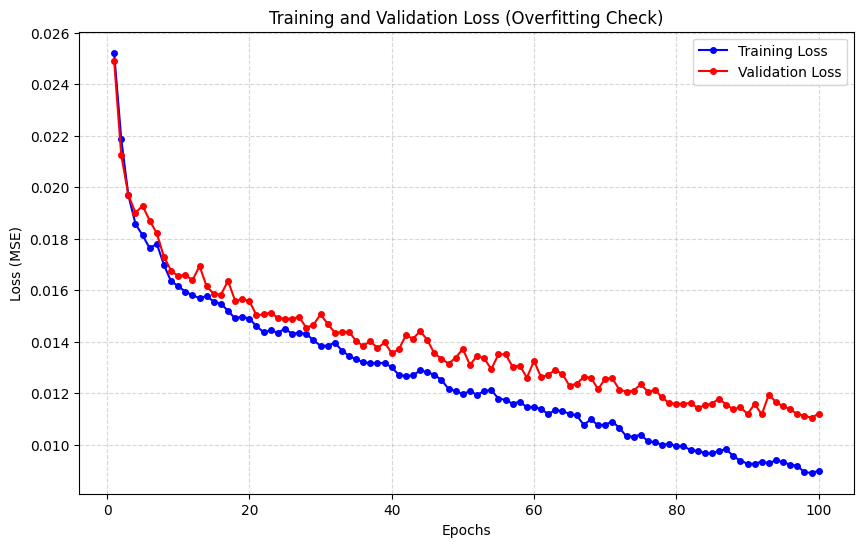

In [5]:
# 학습 결과(history)에서 손실 값 추출
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))

# Train Loss 그래프
plt.plot(epochs, train_loss, 'bo-', label='Training Loss', markersize=4)
# Validation Loss 그래프
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss', markersize=4)

plt.title('Training and Validation Loss (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 5. 결과 시각화
학습된 모델에게 얼굴 윗부분만 보여주고, 모델이 생성한 아랫부분을 실제 아랫부분과 비교
샘플데이터 중 5개만 불러와서 테스트 함

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


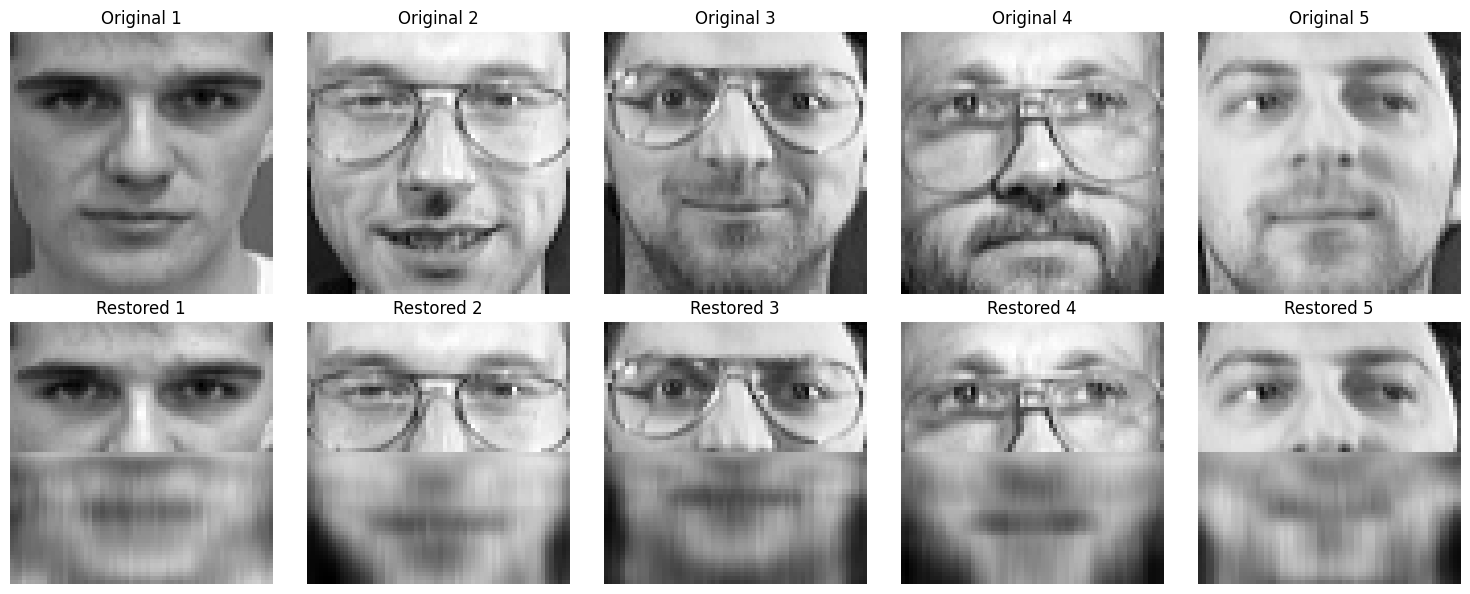

In [6]:
# 테스트 데이터(상단부)를 넣어 하단부 예측값 얻기
predicted_y = model.predict(train_X[:5])

plt.figure(figsize=(15, 6))
for i in range(5):
    # 1. 모델이 예측한 하단부와 상단부를 이어 붙임
    restored_face = np.vstack((train_X[i], predicted_y[i]))
    
    # 2. 실제 원본 이미지 (상단 + 실제 하단)
    original_face = np.vstack((train_X[i], train_y[i]))
    
    # 시각화: 왼쪽은 원본, 오른쪽은 모델이 복원한 결과
    plt.subplot(2, 5, i+1)
    plt.imshow(original_face, cmap='gray')
    plt.title(f"Original {i+1}")
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    plt.imshow(restored_face, cmap='gray')
    plt.title(f"Restored {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 6. 모델의 복원 성능 검증 (정답 비교)
학습된 모델에게 상단부(Test_X)를 입력으로 주고, 모델이 예측한 하단부(Predicted_y)를 생성합니다. 이후 실제 하단부(Original_y)와 결합하여 두 이미지를 나란히 배치함으로써 모델의 복원 정확도를 시각적으로 평가

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


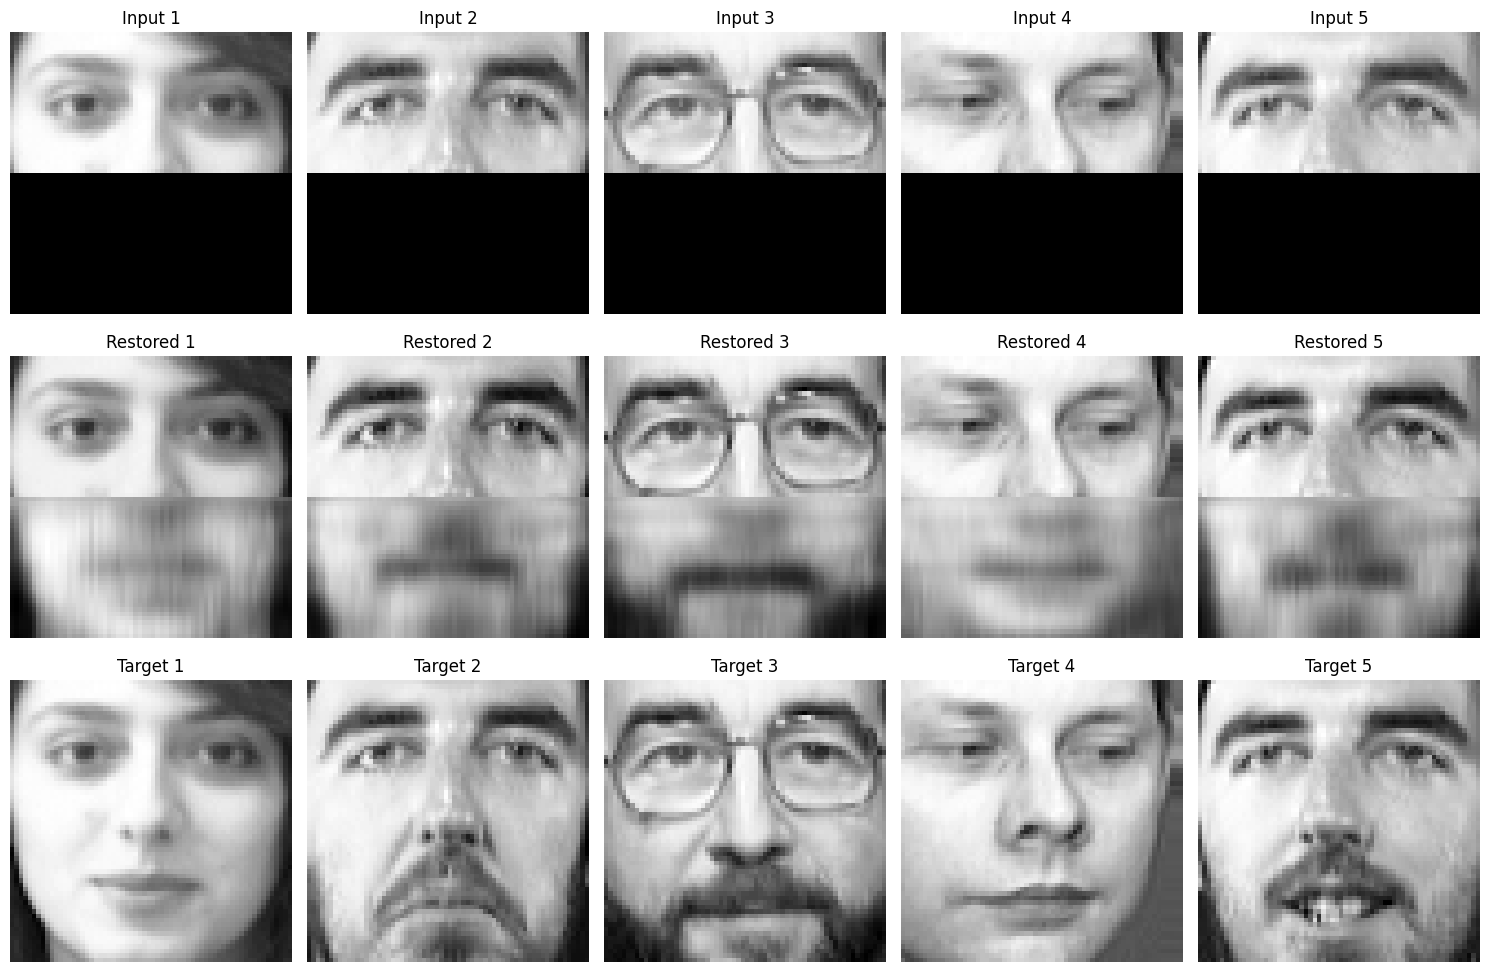

In [7]:
# 1. 테스트용 데이터 선택 (학습에 쓰이지 않은 마지막 5장 선택)
test_indices = range(795, 800)
test_inputs = train_X[test_indices]
test_targets = train_y[test_indices]

# 2. 모델에게 하단부 예측 시키기
predictions = model.predict(test_inputs)

# 3. 시각화 (입력 / 복원 결과 / 실제 정답)
plt.figure(figsize=(15, 10))

for i in range(5):
    # [A] 입력 이미지 (상단부만 있고 하단은 검은색)
    input_img = np.vstack((test_inputs[i], np.zeros((32, 64))))
    
    # [B] 모델이 복원한 이미지 (상단부 + 예측된 하단부)
    restored_img = np.vstack((test_inputs[i], predictions[i]))
    
    # [C] 실제 정답 이미지 (상단부 + 실제 하단부)
    actual_img = np.vstack((test_inputs[i], test_targets[i]))
    
    # 시각화 배치
    # 첫 번째 줄: 입력 이미지
    plt.subplot(3, 5, i + 1)
    plt.imshow(input_img, cmap='gray')
    plt.title(f"Input {i+1}")
    plt.axis('off')
    
    # 두 번째 줄: 모델의 복원 결과
    plt.subplot(3, 5, i + 6)
    plt.imshow(restored_img, cmap='gray')
    plt.title(f"Restored {i+1}")
    plt.axis('off')
    
    # 세 번째 줄: 실제 정답
    plt.subplot(3, 5, i + 11)
    plt.imshow(actual_img, cmap='gray')
    plt.title(f"Target {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 7. 모델 복원 정확도 수치화 (MSE & PSNR)
모델이 생성한 하단부와 실제 하단부의 차이를 두 가지 지표로 계산
MSE (Mean Squared Error): 평균 제곱 오차. 0에 가까울수록 정답과 완벽하게 일치함을 의미
PSNR (Peak Signal-to-Noise Ratio): 최대 신호 대 잡음비. 이미지 복원 품질을 평가할 때 쓰이며, 값이 높을수록(보통 20~30dB 이상) 원본과 유사하다고 판단

In [8]:
from sklearn.metrics import mean_squared_error
import math

# 1. 전체 테스트 데이터에 대한 예측 수행
test_inputs = train_X[700:]  # 검증용 데이터 (약 100장)
test_targets = train_y[700:]
predictions = model.predict(test_inputs)

# 2. MSE 계산 (픽셀 값의 평균 차이)
mse_score = mean_squared_error(test_targets.reshape(-1), predictions.reshape(-1))

# 3. PSNR 계산 (이미지 품질 지수)
def calculate_psnr(mse):
    if mse == 0:
        return 100
    max_pixel = 1.0  # 데이터가 0~1 사이로 정규화되어 있음
    return 20 * math.log10(max_pixel / math.sqrt(mse))

psnr_score = calculate_psnr(mse_score)

print(f"📊 모델 복원 정확도 점검 결과")
print(f"-------------------------------")
print(f"1. Mean Squared Error (MSE): {mse_score:.4f}")
print(f"2. Peak Signal-to-Noise Ratio (PSNR): {psnr_score:.2f} dB")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
📊 모델 복원 정확도 점검 결과
-------------------------------
1. Mean Squared Error (MSE): 0.0114
2. Peak Signal-to-Noise Ratio (PSNR): 19.45 dB


## 8. 어느 부위(코, 입, 턱)를 특히 못 맞췄는지 눈으로 확인
정답과 예측값의 차이(절대값)를 그려보면 모델의 취약점을 알 수 있음
Model Prediction (모델 예측): 전반적인 얼굴 하단부의 '위치'와 '윤곽'은 잡았지만, 매우흐릿. 입술선, 코의 형태 뭉개짐.
Actual Target (실제 정답): 원본 이미지로, 입술 주위의 잔주름, 콧망울의 형태, 턱선 등이 선명하게 보임
Error Map (Difference) (오차 지도): 가장 중요한 이미지입니다. 밝고 노란/붉은 영역이 오차가 큰곳. 검은 영역은 모델이 정확히 맞춘 부분

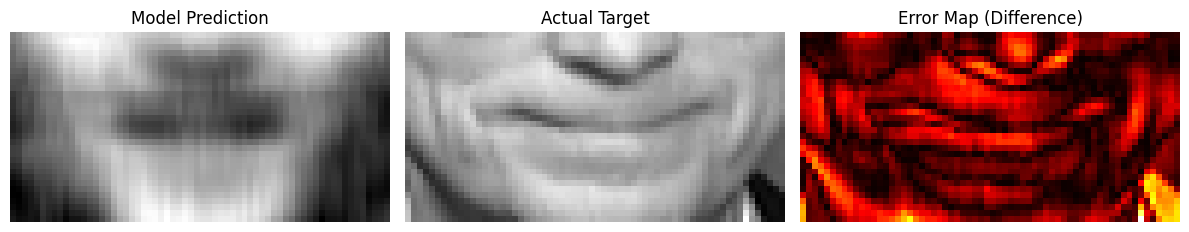

In [9]:
# 첫 번째 테스트 샘플의 오차 맵(Error Map) 생성
error_map = np.abs(test_targets[0] - predictions[0])

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(predictions[0], cmap='gray')
plt.title("Model Prediction")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(test_targets[0], cmap='gray')
plt.title("Actual Target")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(error_map, cmap='hot') # 차이가 클수록 밝게 표시됨
plt.title("Error Map (Difference)")
plt.axis('off')

plt.tight_layout()
plt.show()

## 9. 얼굴 하단부 정밀 오차 분석
MSE가 크다는 것은 델이 정답(실제 얼굴 하단부)을 제대로 맞추지 못하고 엉뚱한 값을 출력했다는 뜻

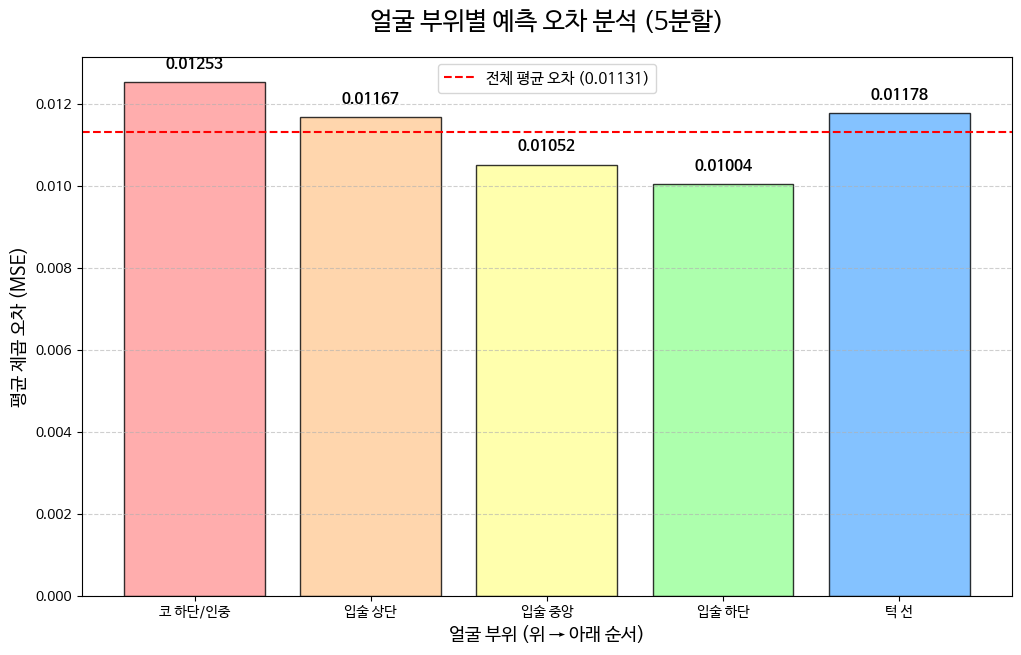

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (코랩/로컬 환경 대응)
import platform
from matplotlib import font_manager, rc

# 한글 폰트 설정 (Windows나 Colab 환경에 맞게 자동 선택)
if platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
    rc('font', family=font_name)
else:    
    # 코랩(Colab) 환경인 경우 나눔폰트가 설치되어 있어야 함 (기본은 고딕체)
    rc('font', family='NanumBarunGothic') 

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 2. 구역 설정 (하단 32행을 5개 구역으로 나눔)
split_indices = [0, 7, 13, 19, 25, 32]
labels = ['코 하단/인중', '입술 상단', '입술 중앙', '입술 하단', '턱 선']
colors = ['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#66b3ff']

# 3. 구역별 MSE 계산
zone_mses = []
for i in range(5):
    start, end = split_indices[i], split_indices[i+1]
    # (샘플수, 해당구역 행수, 64) 범위의 오차 평균
    mse = np.mean(np.square(test_targets[:, start:end, :] - predictions[:, start:end, :]))
    zone_mses.append(mse)

# 4. 막대 차트 시각화
plt.figure(figsize=(12, 7))
bars = plt.bar(labels, zone_mses, color=colors, edgecolor='black', alpha=0.8)

# 막대 위에 정확한 수치 표시 (소수점 5자리)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(zone_mses)*0.02), f'{yval:.5f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('얼굴 부위별 예측 오차 분석 (5분할)', fontsize=18, pad=20)
plt.ylabel('평균 제곱 오차 (MSE)', fontsize=13)
plt.xlabel('얼굴 부위 (위 → 아래 순서)', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 전체 평균 선 추가 (비교 기준)
avg_mse = np.mean(zone_mses)
plt.axhline(y=avg_mse, color='red', linestyle='--', label=f'전체 평균 오차 ({avg_mse:.5f})')
plt.legend(fontsize=11)

plt.show()